# Problem statement
https://www.pp.rhul.ac.uk/~cowan/stat/exercises_full/mlFit/ml_fit_exercise.pdf

Solutions built on the information given at https://github.com/KMISchool2022 & Bapi's repo https://github.com/Bapi2X22/Stat_HEP_Exercise_2026 along with some coding using ChatGPT. Also, check these slides https://github.com/KMISchool2022/excercise/blob/main/cowan_kmi22_exercises.pdf

# Maximum-Likelihood Fitting — Exercise 1 Solution

A complete worked Jupyter-notebook solution to the supplied **Maximum-Likelihood Fitting** exercise, parts **(a)–(e)**.

The model is a mixture of a truncated Gaussian signal and a truncated exponential background:
$$
f(x;\theta,\mu,\sigma,\xi)=\theta f_s(x;\mu,\sigma)+(1-\theta)f_b(x;\xi),
$$
with $(0\le x\le x_{\max})$.

The notebook covers:
- fitted PDF and likelihood scan;
- likelihood contour and confidence regions;
- the $1/\sqrt n$ uncertainty scaling;
- changing the number of free parameters;
- an auxiliary Gaussian measurement of $\xi$.

A fixed random seed is used so the numerical example is reproducible.

## 0. Setup
For an unbinned sample,
$$
L(\boldsymbol\lambda)=\prod_{i=1}^n f(x_i;\boldsymbol\lambda),
\qquad
-\ln L=-\sum_i\ln f(x_i;\boldsymbol\lambda).
$$

The exercise uses $(\theta)$ as the signal fraction and $(\xi)$ as the exponential-background shape parameter.

## Model and data generation

Use the default values
$$
\theta=0.2,\quad \mu=10,\quad \sigma=2,\quad \xi=5,
$$
with $(0\le x\le20)$ and $(n=200)$.

In [1]:
# Example of maximum-likelihood fit with iminuit version 2.
# pdf is a mixture of Gaussian (signal) and exponential (background),
# truncated in [xMin,xMax].
# G. Cowan / RHUL Physics / December 2022

import numpy as np
import scipy.stats as stats
from scipy.stats import truncexpon
from scipy.stats import truncnorm
from scipy.stats import chi2
from scipy.stats import norm
import iminuit
from iminuit import Minuit
import matplotlib.pyplot as plt
from matplotlib import container
plt.rcParams["font.size"] = 14
print("iminuit version:", iminuit.__version__)  # need 2.x

iminuit version: 2.32.0


In [2]:
# define pdf and generate data
np.random.seed(seed=1234567)   
theta_true = 0.2
mu_true = 10.0
sigma_true = 2.0
xi_true = 5.0

xMin = 0.0
xMax = 20.0
numVal = 200

def pdf(x, par):
    theta, mu, sigma, xi = par

    fs = truncnorm.pdf(
        x, a=(xMin-mu)/sigma, b=(xMax-mu)/sigma,
        loc=mu, scale=sigma
    )
    fb = truncexpon.pdf(
        x, b=(xMax-xMin)/xi, loc=xMin, scale=xi
    )
    return theta*fs + (1.0-theta)*fb


def generate_data(numVal, theta=theta_true, mu=mu_true,
                  sigma=sigma_true, xi=xi_true):
    xData = np.empty(numVal)

    for i in range(numVal):
        r = np.random.uniform()

        if r < theta:
            xData[i] = truncnorm.rvs(
                a=(xMin-mu)/sigma, b=(xMax-mu)/sigma,
                loc=mu, scale=sigma
            )
        else:
            xData[i] = truncexpon.rvs(
                b=(xMax-xMin)/xi, loc=xMin, scale=xi
            )
    return xData


xData = generate_data(numVal)

print("Number of events:", len(xData))
print("Range:", xData.min(), "to", xData.max())

Number of events: 200
Range: 0.005163840234942338 to 19.27276850191363


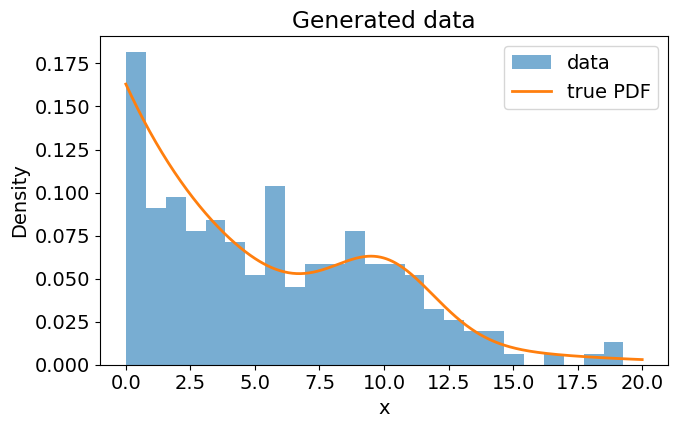

In [3]:
xplot = np.linspace(xMin, xMax, 500)

plt.figure(figsize=(7,4.5))
plt.hist(xData, bins=25, density=True, alpha=0.6, label="data")
plt.plot(
    xplot,
    pdf(xplot, [theta_true, mu_true, sigma_true, xi_true]),
    lw=2, label="true PDF"
)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Generated data")
plt.legend()
plt.tight_layout()
plt.show()

# 1(a) Maximum-likelihood fit
By default, $\theta$ and $\xi$ are free while $\mu$ and $\sigma$ are fixed. 

Minuit uses `errordef = 0.5`, corresponding to the contour
$$
-\ln L=-\ln L_{\min}+\frac12.
$$

In [4]:
def negLogL(par):
    fx = pdf(xData, par)
    if np.any(fx <= 0):
        return np.inf
    return -np.sum(np.log(fx))


parin = np.array([theta_true, mu_true, sigma_true, xi_true])
parname = ["theta", "mu", "sigma", "xi"]
parstep = np.array([0.1, 1.0, 1.0, 1.0])
parfix = [False, True, True, False]
parlim = [(0.0,1.0), (None,None), (0.0,None), (0.0,None)]

m = Minuit(negLogL, parin, name=parname)
m.errors = parstep
m.fixed = parfix
m.limits = parlim
m.errordef = 0.5
m.migrad()

MLE = np.array(m.values)
sigmaMLE = np.array(m.errors)
cov = np.array(m.covariance)
rho = np.array(m.covariance.correlation())

print("Parameter       MLE          Std. dev.")
print("---------------------------------------")
for i, name in enumerate(parname):
    if not m.fixed[i]:
        print(f"{name:8s}   {MLE[i]:10.6f}   +/- {sigmaMLE[i]:.6f}")

print("\nCovariance matrix:")
print(cov)

print("\nCorrelation matrix:")
print(rho)

Parameter       MLE          Std. dev.
---------------------------------------
theta        0.204551   +/- 0.052736
xi           5.107878   +/- 0.644563

Covariance matrix:
[[ 0.00279707  0.          0.         -0.01813056]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [-0.01813056  0.          0.          0.41559083]]

Correlation matrix:
[[ 1.          0.          0.         -0.53177377]
 [ 0.          0.          0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [-0.53177377  0.          0.          1.        ]]


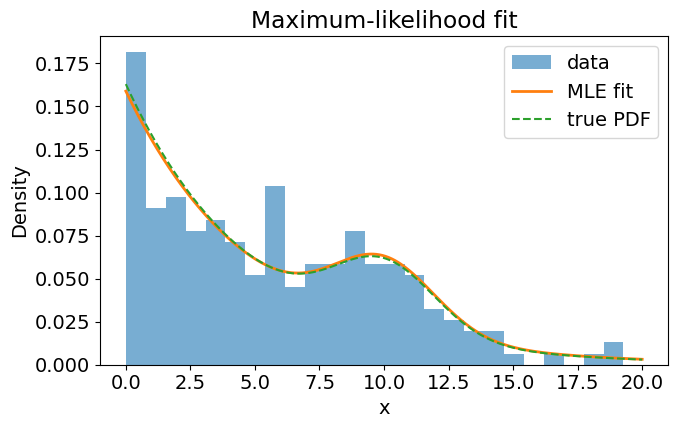

In [5]:
plt.figure(figsize=(7,4.5))
plt.hist(xData, bins=25, density=True, alpha=0.6, label="data")
plt.plot(xplot, pdf(xplot, MLE), lw=2, label="MLE fit")
plt.plot(
    xplot,
    pdf(xplot, [theta_true, mu_true, sigma_true, xi_true]),
    "--", lw=1.5, label="true PDF"
)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Maximum-likelihood fit")
plt.legend()
plt.tight_layout()
plt.show()

### Profile likelihood scan in $\theta$

For fixed $\theta$, minimize over the nuisance parameter $\xi$. Near the minimum,
$$
-\ln L(\theta)\approx-\ln L_{\min}
+\frac{(\theta-\hat\theta)^2}{2\sigma_{\hat\theta}^2}.
$$

Therefore the crossings of
$$
-\ln L=-\ln L_{\min}+\frac12
$$
occur approximately at $$ \hat\theta\pm\sigma_{\hat\theta} $$.

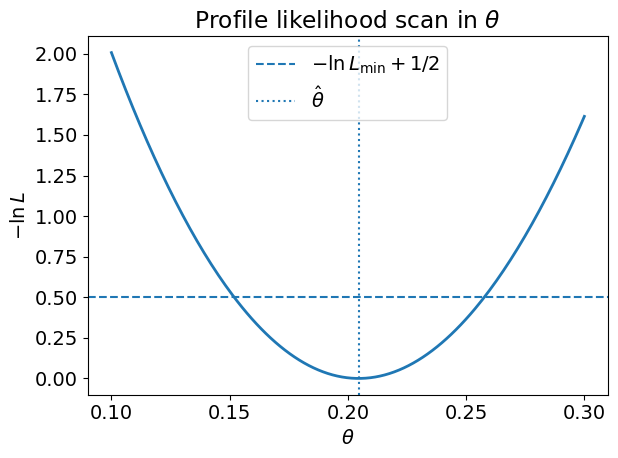

theta_hat = 0.204551
sigma_theta from Minuit = 0.052736


In [9]:
## Added by Seema - manually profiling over xi
#theta_scan = np.linspace(0.001, 0.999, 200)
theta_scan = np.linspace(0.1, 0.3, 200)
nll_scan = []

for th in theta_scan:
    def nll_xi(xi):
        return negLogL([th, mu_true, sigma_true, xi])

    mm = Minuit(nll_xi, xi=MLE[3])
    mm.limits["xi"] = (1e-6, None)
    mm.errordef = 0.5
    mm.migrad()
    nll_scan.append(mm.fval)

nll_scan = np.asarray(nll_scan)
nll_min = m.fval

#plt.figure(figsize=(7,4.5))
plt.figure()
#plt.plot(theta_scan, nll_scan, lw=2)
plt.plot(theta_scan, nll_scan - nll_min, lw=2)
#plt.axhline(nll_min+0.5, ls="--", label=r"$-\ln L_{\min}+1/2$")
plt.axhline(0.5, ls="--", label=r"$-\ln L_{\min}+1/2$")
plt.axvline(MLE[0], ls=":", label=r"$\hat\theta$")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$-\ln L$")
plt.title(r"Profile likelihood scan in $\theta$")
plt.legend()
plt.tight_layout()
plt.show()

print(f"theta_hat = {MLE[0]:.6f}")
print(f"sigma_theta from Minuit = {sigmaMLE[0]:.6f}")

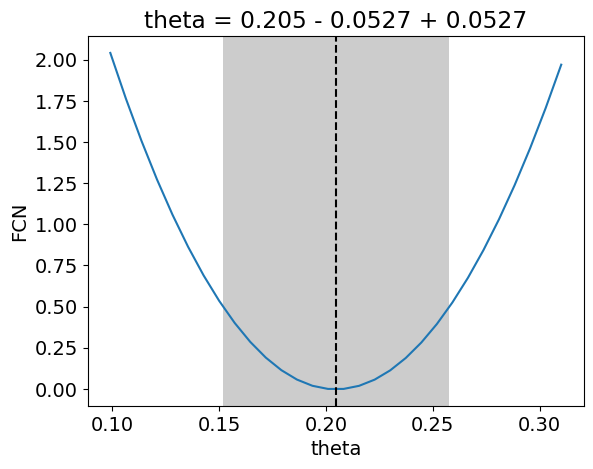

In [10]:
# original code - using minuit functionality
# Make scan of lnL (for theta, if free) 
if not(m.fixed['theta']):
    plt.figure()
    m.draw_mnprofile('theta')
    plt.show()

### Likelihood contour in $(\theta,\xi)$

The 1-sigma contour is
$$
\Delta(-\ln L)=\frac12.
$$

The tangent-line distances from the MLE give the parameter standard deviations, while the tilt of the ellipse reflects the correlation between $\theta$ and $\xi$.

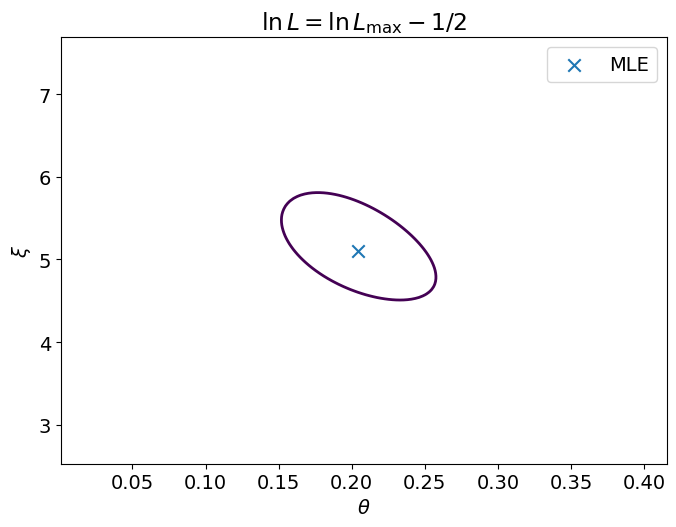

In [11]:
theta_grid = np.linspace(
    max(0.001, MLE[0]-4*sigmaMLE[0]),
    min(0.999, MLE[0]+4*sigmaMLE[0]), 160
)
xi_grid = np.linspace(
    max(0.05, MLE[3]-4*sigmaMLE[3]),
    MLE[3]+4*sigmaMLE[3], 160
)

NLL = np.empty((len(xi_grid), len(theta_grid)))

for iy, xi in enumerate(xi_grid):
    for ix, th in enumerate(theta_grid):
        NLL[iy, ix] = negLogL([th, mu_true, sigma_true, xi])

deltaNLL = NLL - nll_min

plt.figure(figsize=(7,5.5))
cs = plt.contour(theta_grid, xi_grid, deltaNLL, levels=[0.5], linewidths=2)
plt.clabel(cs, inline=True, fmt={0.5:r"$\Delta(-\ln L)=0.5$"})
plt.scatter(MLE[0], MLE[3], marker="x", s=80, label="MLE")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\xi$")
plt.title(r"$\ln L=\ln L_{\max}-1/2$")
plt.legend()
plt.tight_layout()
plt.show()

### Confidence regions

For $N=2$ fitted parameters,
$\Delta(-\ln L) = -\ln L(\theta) - (-\ln L_{\min}) = \frac{1}{2} \chi^2_{1,\,\alpha}$

Thus the 68.3% and 95% contours correspond approximately to
$$
\Delta(-\ln L)=1.15,\qquad 2.996.
$$

The expression
```python
stats.chi2.cdf(1., 2)
```
is the probability $P(\chi^2_2\le1)$, approximately 0.3935. It is the confidence level associated with a two-parameter contour having $\Delta(-\ln L)=1/2$, because $2\Delta(-\ln L)=1$.

CL = 68.3% : Delta(-ln L) = 1.1489
CL = 95.0% : Delta(-ln L) = 2.9957


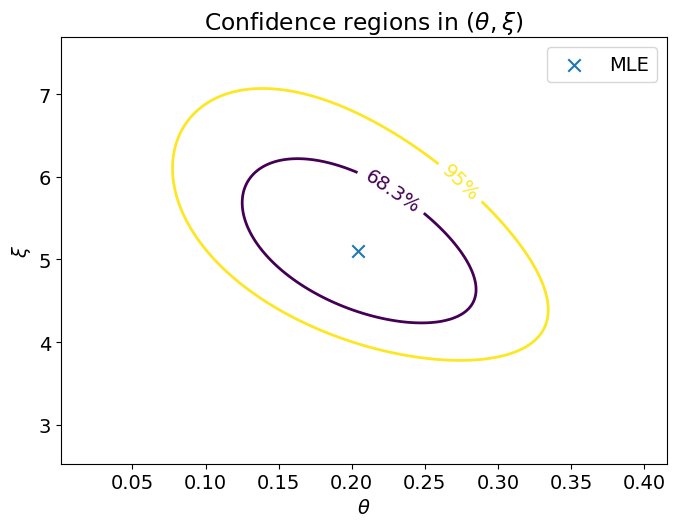

In [12]:
CLs = [0.683, 0.95]
delta_levels = [0.5*chi2.ppf(CL, df=2) for CL in CLs]

for CL, lev in zip(CLs, delta_levels):
    print(f"CL = {100*CL:.1f}% : Delta(-ln L) = {lev:.4f}")

plt.figure(figsize=(7,5.5))
cs = plt.contour(
    theta_grid, xi_grid, deltaNLL,
    levels=delta_levels, linewidths=2
)

plt.clabel(
    cs, inline=True,
    fmt={delta_levels[0]:"68.3%", delta_levels[1]:"95%"}
)

plt.scatter(MLE[0], MLE[3], marker="x", s=80, label="MLE")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\xi$")
plt.title(r"Confidence regions in $(\theta,\xi)$")
plt.legend()
plt.tight_layout()
plt.show()

## 1(b) $1/\sqrt n$ scaling

For iid observations,
$$
L(\boldsymbol\lambda)=\prod_{i=1}^n f(x_i;\boldsymbol\lambda),
$$
so
$$
\ln L=\sum_{i=1}^n\ln f(x_i;\boldsymbol\lambda).
$$

Therefore the Fisher information is (Check Cowan section 6.6, equation 6.20)
$$
V^{-1}_{ij}
=
-E\left[
\frac{\partial^2\ln L}
{\partial\lambda_i\partial\lambda_j}
\right]
=
-n\,E\left[
\frac{\partial^2\ln f}
{\partial\lambda_i\partial\lambda_j}
\right].
$$

Hence
$$
V^{-1}\propto n
\quad\Rightarrow\quad
V\propto\frac1n.
$$

Since the variance is proportional to \(1/n\), the standard deviation is
$$
\boxed{\sigma_{\hat\lambda}\propto\frac1{\sqrt n}}.
$$

# 1(c) Dependence on sample size

Repeat the fit for $n=100,200,400,800$ and record $\sigma_{\hat\theta}$.

In [13]:
def fit_sample(xData, parfix):
    def nll(par):
        fx = pdf(xData, par)
        if np.any(fx <= 0):
            return np.inf
        return -np.sum(np.log(fx))

    mlocal = Minuit(
        nll,
        np.array([theta_true, mu_true, sigma_true, xi_true]),
        name=parname
    )
    mlocal.errors = parstep
    mlocal.fixed = parfix
    mlocal.limits = parlim
    mlocal.errordef = 0.5
    mlocal.migrad()

    return (
        np.array(mlocal.values),
        np.array(mlocal.errors),
        np.array(mlocal.covariance),
        mlocal
    )


np.random.seed(2022)

sample_sizes = [100, 200, 400, 800]
theta_errors = []
theta_estimates = []

for n in sample_sizes:
    data_n = generate_data(n)
    mle_n, err_n, cov_n, m_n = fit_sample(
        data_n, [False, True, True, False]
    )
    theta_estimates.append(mle_n[0])
    theta_errors.append(err_n[0])

print(" n      theta_hat      sigma_theta")
print("------------------------------------")
for n, th, err in zip(sample_sizes, theta_estimates, theta_errors):
    print(f"{n:4d}    {th:10.5f}     {err:10.5f}")

 n      theta_hat      sigma_theta
------------------------------------
 100       0.20035        0.07998
 200       0.19557        0.05078
 400       0.25178        0.03733
 800       0.21344        0.02661


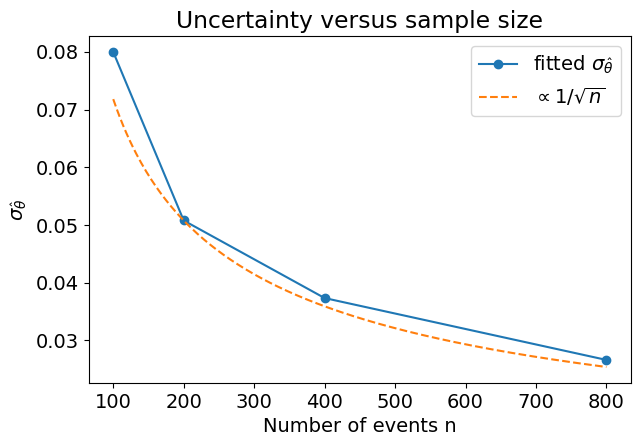

In [14]:
plt.figure(figsize=(7, 4.5))

plt.plot(sample_sizes, theta_errors, "o-",label=r"fitted $\sigma_{\hat\theta}$")

# Reference curve proportional to 1/sqrt(n)
reference = theta_errors[1] * np.sqrt(200)
n_dense = np.linspace(100, 800, 300)

plt.plot(n_dense, reference / np.sqrt(n_dense), "--",label=r"$\propto 1/\sqrt{n}$")

plt.xlabel("Number of events n")
plt.ylabel(r"$\sigma_{\hat\theta}$")
plt.title(r"Uncertainty versus sample size")
plt.legend()
# plt.tight_layout()   # remove this
plt.show()

**Comment:** individual values fluctuate because the samples are random, but the overall trend should follow \(1/\sqrt n\). Multiplying \(n\) by four should approximately halve the typical uncertainty.

# 1(d) Number of adjustable parameters

The four requested cases are:

1. $\theta$ free; $\mu,\sigma,\xi$ fixed.
2. $\theta,\xi$ free; $\mu,\sigma$ fixed.
3. $\theta,\xi,\sigma$ free; $\mu$ fixed.
4. $\theta,\xi,\mu,\sigma$ all free.

The same data sample is used for all four fits.

In [15]:
np.random.seed(314159)
data_d = generate_data(200)

cases = {
    "theta only": [False, True, True, True],
    "theta + xi": [False, True, True, False],
    "theta + xi + sigma": [False, True, False, False],
    "theta + xi + mu + sigma": [False, False, False, False],
}

results_d = {}

for label, fixed in cases.items():
    results_d[label] = fit_sample(data_d, fixed)

print("Case                         theta_hat       sigma_theta")
print("---------------------------------------------------------")

for label, (mle_d, err_d, cov_d, md) in results_d.items():
    print(f"{label:28s} {mle_d[0]:10.5f}       {err_d[0]:10.5f}")

Case                         theta_hat       sigma_theta
---------------------------------------------------------
theta only                      0.17217          0.04472
theta + xi                      0.11157          0.05582
theta + xi + sigma              0.40219          0.08990
theta + xi + mu + sigma         0.65157          0.18837


**Comment:** allowing nuisance parameters to float generally increases the uncertainty on $\hat\theta$, because uncertainty and correlations in the nuisance parameters propagate into the parameter of interest. The exact numerical values depend on the random sample.

# 1(e) Auxiliary measurement of $\xi$

Suppose
$$
u\sim N(\xi,\sigma_u),
\qquad
u=5,\qquad \sigma_u=0.5.
$$

The independent auxiliary measurement contributes
$$
-\ln L_u=
\frac12\left(\frac{\xi-u}{\sigma_u}\right)^2
$$
up to an irrelevant additive constant.

Therefore
$$
-\ln L_{\rm total}
=
-\ln L_x+
\frac12\left(\frac{\xi-u}{\sigma_u}\right)^2.
$$

In [17]:
u = 5.0
sigma_u = 0.5

def negLogL_with_aux(par):
    fx = pdf(xData, par)
    if np.any(fx <= 0):
        return np.inf
    nll_primary = -np.sum(np.log(fx))
    xi = par[3]
    nll_aux = 0.5*((xi-u)/sigma_u)**2
    return nll_primary + nll_aux

m_aux = Minuit(negLogL_with_aux, parin, name=parname)
m_aux.errors = parstep
m_aux.fixed = [False, True, True, False]
m_aux.limits = parlim
m_aux.errordef = 0.5
m_aux.migrad()

MLE_aux = np.array(m_aux.values)
sigma_aux = np.array(m_aux.errors)

print("With auxiliary measurement:")
print(f"theta = {MLE_aux[0]:.6f} +/- {sigma_aux[0]:.6f}")
print(f"xi    = {MLE_aux[3]:.6f} +/- {sigma_aux[3]:.6f}")

print("\nWithout auxiliary measurement:")
print(f"theta = {MLE[0]:.6f} +/- {sigmaMLE[0]:.6f}")
print(f"xi    = {MLE[3]:.6f} +/- {sigmaMLE[3]:.6f}")

With auxiliary measurement:
theta = 0.207539 +/- 0.047847
xi    = 5.041306 +/- 0.391524

Without auxiliary measurement:
theta = 0.204551 +/- 0.052736
xi    = 5.107878 +/- 0.644563


The auxiliary measurement supplies additional information about $\xi$. Because $\theta$ and $\xi$ are correlated, constraining $\xi$ also reduces the uncertainty on $\theta$.

Thus the expected qualitative result is
$$
\boxed{\sigma_{\hat\xi}\text{ decreases}}
\qquad\text{and}\qquad
\boxed{\sigma_{\hat\theta}\text{ decreases}}.
$$

This corresponds to a smaller likelihood/confidence ellipse.

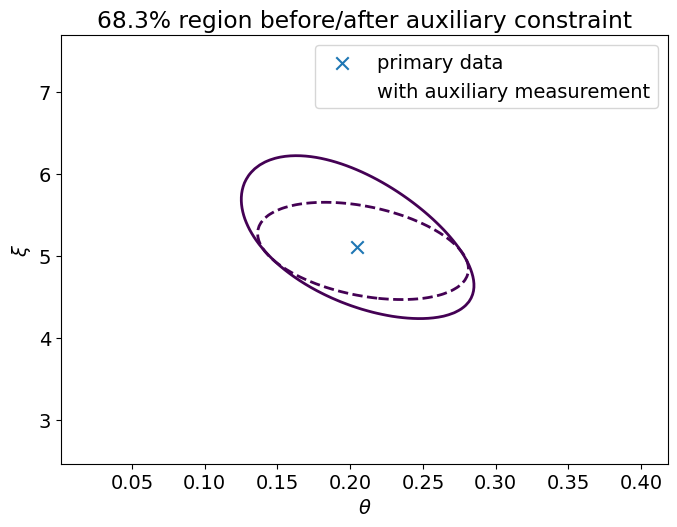

In [18]:
# Compare the 68.3% likelihood contour before and after the auxiliary measurement

theta_grid_e = np.linspace(
    max(0.001, min(MLE[0], MLE_aux[0]) - 4*max(sigmaMLE[0], sigma_aux[0])),
    min(0.999, max(MLE[0], MLE_aux[0]) + 4*max(sigmaMLE[0], sigma_aux[0])),
    120
)

xi_grid_e = np.linspace(
    max(0.05, min(MLE[3], MLE_aux[3]) - 4*max(sigmaMLE[3], sigma_aux[3])),
    max(MLE[3], MLE_aux[3]) + 4*max(sigmaMLE[3], sigma_aux[3]),
    120
)

NLL_primary = np.empty((len(xi_grid_e), len(theta_grid_e)))
NLL_aux = np.empty_like(NLL_primary)

for iy, xi in enumerate(xi_grid_e):
    for ix, th in enumerate(theta_grid_e):
        pars = [th, mu_true, sigma_true, xi]
        NLL_primary[iy, ix] = negLogL(pars)
        NLL_aux[iy, ix] = negLogL_with_aux(pars)

NLL_primary -= NLL_primary.min()
NLL_aux -= NLL_aux.min()

level_68 = 0.5*chi2.ppf(0.683, 2)

plt.figure(figsize=(7,5.5))
plt.contour(
    theta_grid_e, xi_grid_e, NLL_primary,
    levels=[level_68], linewidths=2, linestyles="-"
)
plt.contour(
    theta_grid_e, xi_grid_e, NLL_aux,
    levels=[level_68], linewidths=2, linestyles="--"
)

plt.scatter(MLE[0], MLE[3], marker="x", s=80, label="primary data")
plt.scatter(
    MLE_aux[0], MLE_aux[3],
    marker="o", facecolors="none", s=80,
    label="with auxiliary measurement"
)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$\xi$")
plt.title("68.3% region before/after auxiliary constraint")
plt.legend()
plt.tight_layout()
plt.show()

# Final answers at a glance

**(a)** The minimum of $-\ln L$ gives the MLEs. The $\Delta(-\ln L)=1/2$ rule gives the 1-sigma contour, and its tangent-line distances agree with the Minuit errors.

**(b)** For iid data, Fisher information is proportional to \(n\), so covariance is proportional to \(1/n\), giving
$$
\sigma_{\hat\lambda}\propto1/\sqrt n.
$$

**(c)** The fitted $\sigma_{\hat\theta}$ decreases approximately as $1/\sqrt n$.

**(d)** Making nuisance parameters free generally increases $\sigma_{\hat\theta}$.

**(e)** Adding the independent Gaussian constraint on $\xi$ reduces the uncertainty on $\xi$, and because of the $\theta-\xi$ correlation it also reduces the uncertainty on $\theta$.